In [21]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib
import random
import pickle
import numpy as np
import pandas as pd
import tempfile
import argparse
from datetime import datetime

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
from sklearn.metrics import roc_curve, precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

import ray
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
import shap
import matplotlib.pyplot as plt

import config
from preprocessing_utils import ClinicalPreprocessorWrapper, MrnaPreprocessorWrapper, MutationPreprocessorWrapper
from model_utils import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_random_seed(config.SEED)

In [31]:
print("Loading data...")

X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))

clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

# Load best hyperparameters
# with open('RandomForest_raytune_results.pkl', 'rb') as f:
#     RandomForest_raytune_kfold_results = pickle.load(f)

# print(f"Loaded RandomForest_raytune_kfold_results: {RandomForest_raytune_kfold_results}")
# best_config = RandomForest_raytune_kfold_results["best_hyperparams"]
with open('RandomForest_raytune_best_hyperparams.pkl', 'rb') as f:
    best_config = pickle.load(f)

print(f"Loaded best_config: {best_config}")


# Split by modality
clinical_train = X_train[clinical_cols]
mrna_train = X_train[mrna_cols]
mutation_train = X_train[mutation_cols]

clinical_val= X_val[clinical_cols]
mrna_val = X_val[mrna_cols]
mutation_val = X_val[mutation_cols]

clinical_test = X_test[clinical_cols]
mrna_test = X_test[mrna_cols]
mutation_test = X_test[mutation_cols]

clinical_prep = ClinicalPreprocessorWrapper(
    cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
    categorical_cols=config.CATEGORICAL_COLS,
    max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
    uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
)
mrna_prep = MrnaPreprocessorWrapper(
    max_null_frac=config.MAX_NULL_FRAC,
    uniform_thresh=config.UNIFORM_THRESHOLD,
    random_state=config.SEED,
)
mutation_prep = MutationPreprocessorWrapper(
    max_mutation_count=best_config["max_mutation_count"],
    uniform_thresh=best_config["mutation_uniform_thresh"],
)

# Fit preprocessors on training data
clinical_prep.fit(clinical_train)
mrna_prep.fit(mrna_train, y_train)
mutation_prep.fit(mutation_train)

# Transform training and validation data
clinical_train = clinical_prep.transform(clinical_train)
clinical_val = clinical_prep.transform(clinical_val)
clinical_test = clinical_prep.transform(clinical_test)

mrna_train = mrna_prep.transform(mrna_train)
mrna_val = mrna_prep.transform(mrna_val)
mrna_test = mrna_prep.transform(mrna_test)

mut_train = mutation_prep.transform(mutation_train)
mut_val = mutation_prep.transform(mutation_val)
mut_test = mutation_prep.transform(mutation_test)

def apply_feature_selection(estimator, mrna_train, mrna_val, mut_train, mut_val, y_train):
    """Helper function to apply SelectFromModel to both mRNA and mutation data"""
    threshold = best_config["fs_threshold"]
    max_features = best_config["fs_max_features"]

    # Create and fit SelectFromModel for mRNA
    sfm_mrna = SelectFromModel(estimator, threshold=threshold, max_features=max_features)
    sfm_mrna.fit(mrna_train, y_train)

    # Create and fit SelectFromModel for mutations
    sfm_mut = SelectFromModel(estimator, threshold=threshold, max_features=max_features)
    sfm_mut.fit(mut_train, y_train)

    # Transform data
    mrna_train_fs = sfm_mrna.transform(mrna_train)
    mrna_val_fs = sfm_mrna.transform(mrna_val)
    mut_train_fs = sfm_mut.transform(mut_train)
    mut_val_fs = sfm_mut.transform(mut_val)

    return mrna_train_fs, mrna_val_fs, mut_train_fs, mut_val_fs


fs_estimator = RandomForestClassifier(
    n_estimators=best_config["fs_n_estimators"],
    max_depth=best_config["fs_max_depth"],
    random_state=config.SEED
)
mrna_train_new, mrna_val, mut_train_new, mut_val = apply_feature_selection(
    fs_estimator, mrna_train.copy(), mrna_val, mut_train.copy(), mut_val, y_train
)

# Create data loaders
train_loader = to_loader(clinical_train, mrna_train_new, mut_train_new, y_train, shuffle=True)
val_loader = to_loader(clinical_val, mrna_val, mut_val, y_val)

mrna_train, mrna_test, mut_train, mut_test = apply_feature_selection(
    fs_estimator, mrna_train, mrna_test, mut_train, mut_test, y_train
)

test_loader = to_loader(clinical_test, mrna_test, mut_test, y_test)

Loading data...
Loaded best_config: {'fs_method': 'RandomForest', 'clin_hidden': [128], 'mrna_hidden': [64], 'mut_hidden': [128, 64], 'clin_dropout': [0.3, 0.3], 'mrna_dropout': [0.0, 0.0], 'mut_dropout': [0.2, 0.2], 'fusion_hidden': 64, 'fusion_dropout': 0.03177917514301182, 'lr': 8.569331925053982e-05, 'activation': 'silu', 'max_mutation_count': 5, 'mutation_uniform_thresh': 0.9656645560504258, 'optimizer': 'RMSprop', 'weight_decay': 1.2557036943140694e-05, 'momentum': 0.9066362509110633, 'nesterov': True, 'rmsprop_alpha': 0.9118398303478918, 'fs_n_estimators': 100, 'fs_max_depth': 10, 'fs_threshold': 'mean', 'fs_max_features': None}


In [32]:
print(f"Training final model with best hyperparameters:\n{best_config}\n")

# Create final model
final_model = MultimodalNet(
    clin_dim=clinical_train.shape[1],
    mrna_dim=mrna_train.shape[1],
    mut_dim=mut_train.shape[1],
    clin_hidden=best_config["clin_hidden"],
    mrna_hidden=best_config["mrna_hidden"],
    mut_hidden=best_config["mut_hidden"],
    clin_dropout=best_config["clin_dropout"],
    mrna_dropout=best_config["mrna_dropout"],
    mut_dropout=best_config["mut_dropout"],
    activation=best_config.get("activation", "relu"),
    fusion_hidden=best_config["fusion_hidden"],
    fusion_dropout=best_config["fusion_dropout"],
    use_gene_sel=False  # No feature selection
).to(device)

optimizer = build_optimizer(final_model, best_config)
pos_weight_value = torch.tensor(
    (len(y_train) - y_train.sum()) / y_train.sum(), 
    dtype=torch.float32
).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

# Train the final model
best_state = train_one_fold(train_loader, val_loader, final_model, optimizer, criterion, config.SEED, device)
final_model.load_state_dict(best_state)

# Find optimal threshold on validation set
final_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for clin, mrna, mut, y in val_loader:
        clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
        probs = torch.sigmoid(final_model(clin, mrna, mut)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
print("AUROC with best weights (sanity check):", roc_auc_score(all_labels, all_probs))

thresholds = np.linspace(0.001, 0.9, 200)
best_threshold, best_f1_val = 0.5, 0
for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds, zero_division=0)
    if f1 > best_f1_val:
        best_f1_val = f1
        best_threshold = t

print(f"Optimal threshold for validation: {best_threshold:.4f}")

# Evaluate on validation set
val_metrics = evaluate_with_threshold(final_model, val_loader, 0.5, device)
print(f"\nValidation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")

# Save the final model
torch.save(final_model.state_dict(), 'final_model_raytune.pt')
print("\nFinal model saved to 'final_model_raytune.pt'")

Training final model with best hyperparameters:
{'fs_method': 'RandomForest', 'clin_hidden': [128], 'mrna_hidden': [64], 'mut_hidden': [128, 64], 'clin_dropout': [0.3, 0.3], 'mrna_dropout': [0.0, 0.0], 'mut_dropout': [0.2, 0.2], 'fusion_hidden': 64, 'fusion_dropout': 0.03177917514301182, 'lr': 8.569331925053982e-05, 'activation': 'silu', 'max_mutation_count': 5, 'mutation_uniform_thresh': 0.9656645560504258, 'optimizer': 'RMSprop', 'weight_decay': 1.2557036943140694e-05, 'momentum': 0.9066362509110633, 'nesterov': True, 'rmsprop_alpha': 0.9118398303478918, 'fs_n_estimators': 100, 'fs_max_depth': 10, 'fs_threshold': 'mean', 'fs_max_features': None}

Epoch 001 | Train Loss: 0.8623 | Val AUROC: 0.7542 | P: 0.550 | R: 0.917 | F1: 0.688 | TN: 11 | FP: 9 | FN: 1 | TP: 11
Epoch 002 | Train Loss: 0.8316 | Val AUROC: 0.7875 | P: 0.647 | R: 0.917 | F1: 0.759 | TN: 14 | FP: 6 | FN: 1 | TP: 11
Epoch 003 | Train Loss: 0.7932 | Val AUROC: 0.8000 | P: 0.647 | R: 0.917 | F1: 0.759 | TN: 14 | FP: 6 | F

[0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5454545454545454, 0.5581395348837209, 0.5581395348837209, 0.5581395348837209, 0.5581395348837209, 0.5581395348837209, 0.5853658536585366, 0.6153846153846154, 0.6486486486486487, 0.6486486486486487, 0.6486486486486487, 0.6857142857142857, 0.6857142857142857, 0.6470588235294118, 0.6470588235294118, 0.6060606060606061, 0.6060606060606061, 0.5625, 0.6, 0.6206896551724138, 0.5925925925925926, 0.5925925925925926, 0.6153846153846154, 0.6153846153846154, 0.6153846153846154, 0.64, 0.64, 0.64, 0.64, 0.64, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6086956521739131, 0.6086956521739131, 0.6086956521739131, 0.6363636363636364, 0.57142857142857

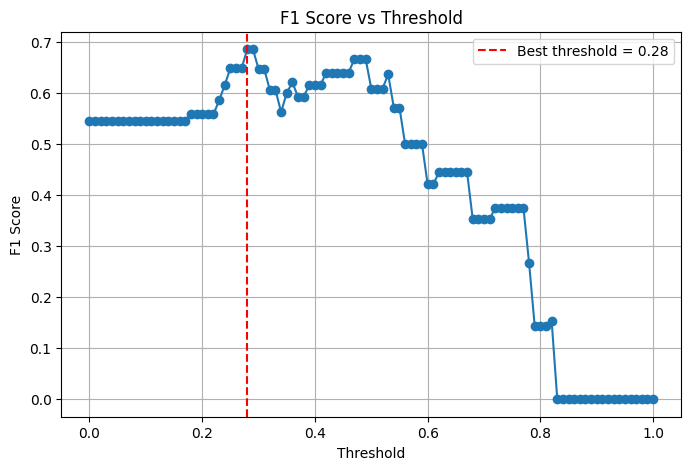

Optimal threshold: 0.28, F1 score: 0.686


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Replace these with your actual arrays
# y_true = np.array([...])
# all_probs = np.array([...])

thresholds = np.linspace(0, 1, 101)  # thresholds from 0 to 1
f1_scores = []

for t in thresholds:
    y_pred = (all_probs >= t).astype(int)
    f1 = f1_score(all_labels, y_pred)
    f1_scores.append(f1)
print(f1_scores)
# Convert to numpy array for convenience
f1_scores = np.array(f1_scores)

# Plot F1 score vs threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', linestyle='-')
plt.title('F1 Score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.grid(True)

# Highlight the threshold with the maximum F1
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.legend()

plt.show()

print(f'Optimal threshold: {best_threshold:.2f}, F1 score: {best_f1:.3f}')



Test metrics:
  auroc: 0.7583
  auprc: 0.6474
  precision: 0.6667
  recall: 0.6667
  f1: 0.6667
  TP: 8.0000
  FP: 4.0000
  TN: 16.0000
  FN: 4.0000


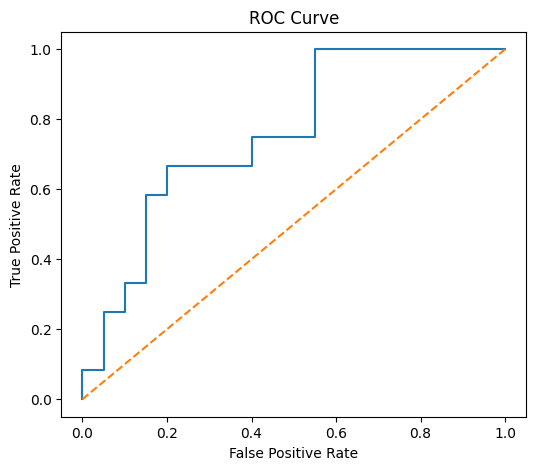

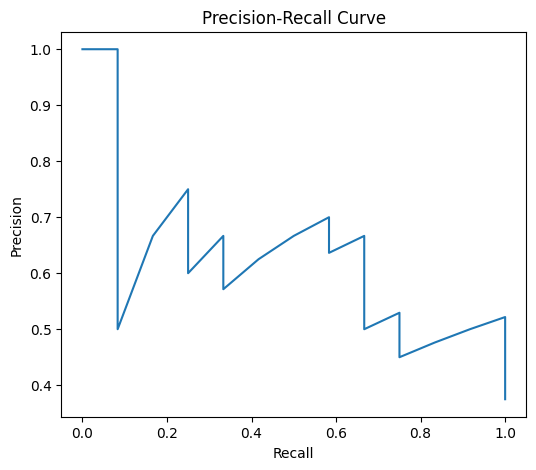

In [37]:
# evaluate on testing data
test_metrics = evaluate_with_threshold(final_model, test_loader, 0.48, device)
print(f"\nTest metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")


final_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for clin, mrna, mut, y in test_loader:
        clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
        probs = torch.sigmoid(final_model(clin, mrna, mut)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# AUROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Precision–Recall curve
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [39]:
# Prepare data (same as training)
print("\nPreparing data for SHAP analysis...")
# Convert to numpy arrays and ensure they are numeric
def to_numeric_array(data):
    """Convert data to numeric numpy array"""
    if isinstance(data, pd.DataFrame):
        return data.to_numpy(dtype=np.float32)
    elif isinstance(data, np.ndarray):
        return data.astype(np.float32)
    else:
        return np.array(data, dtype=np.float32)

clin_test_array = to_numeric_array(clinical_test)
mrna_test_array = to_numeric_array(mrna_test)
mut_test_array = to_numeric_array(mutation_test)

# Get feature names from preprocessed DataFrames
if isinstance(clinical_test, pd.DataFrame):
    clin_feature_names = list(clinical_test.columns)
else:
    clin_feature_names = [f"clinical_{i}" for i in range(clin_test_array.shape[1])]

if isinstance(mrna_test, pd.DataFrame):
    mrna_feature_names = list(mrna_test.columns)
    mrna_feature_names = [item + "_exp" for item in mrna_feature_names]
else:
    mrna_feature_names = [f"mrna_{i}" for i in range(mrna_test_array.shape[1])]

if isinstance(mutation_test, pd.DataFrame):
    mut_feature_names = list(mutation_test.columns)
else:
    mut_feature_names = [f"mutation_{i}" for i in range(mut_test_array.shape[1])]

all_feature_names = clin_feature_names + mrna_feature_names + mut_feature_names

print(f"Number of features: Clinical={len(clin_feature_names)}, mRNA={len(mrna_feature_names)}, Mutation={len(mut_feature_names)}")
print(f"Sample clinical features: {clin_feature_names[:5]}")
print(f"Sample mRNA features: {mrna_feature_names[:5]}")
print(f"Sample mutation features: {mut_feature_names[:5]}")

# Concatenate features
X_test_combined = np.concatenate([clin_test_array, mrna_test_array, mut_test_array], axis=1).astype(np.float32)

print(f"\nCombined feature matrix shape: {X_test_combined.shape}")
print(f"Data type: {X_test_combined.dtype}")

# Store dimensions for splitting
clin_dim = clin_test_array.shape[1]
mrna_dim = mrna_test_array.shape[1]
mut_dim = mut_test_array.shape[1]

# Recreate the model with saved hyperparameters
print("\nRecreating model architecture...")
loaded_model = MultimodalNet(
    clin_dim=clin_dim,
    mrna_dim=mrna_dim,
    mut_dim=mut_dim,
    clin_hidden=best_config["clin_hidden"],
    mrna_hidden=best_config["mrna_hidden"],
    mut_hidden=best_config["mut_hidden"],
    clin_dropout=best_config["clin_dropout"],
    mrna_dropout=best_config["mrna_dropout"],
    mut_dropout=best_config["mut_dropout"],
    activation=best_config.get("activation", "relu"),
    fusion_hidden=best_config["fusion_hidden"],
    fusion_dropout=best_config["fusion_dropout"],
    use_gene_sel=False  # No feature selection
).to(device)

# Load saved weights
loaded_model.load_state_dict(torch.load('final_model_raytune.pt', map_location=device))
loaded_model.eval()

print("Model loaded successfully!")

# Create a wrapper function for the model that takes concatenated input
def model_predict(X):
    """Wrapper function for SHAP that splits concatenated features back into modalities"""
    loaded_model.eval()
    
    # Ensure X is float32 numpy array and 2D
    if not isinstance(X, np.ndarray):
        X = np.array(X, dtype=np.float32)
    else:
        X = X.astype(np.float32)
    
    # Ensure 2D shape
    if len(X.shape) == 1:
        X = X.reshape(1, -1)
    
    # Split features back into modalities
    clin = X[:, :clin_dim]
    mrna = X[:, clin_dim:clin_dim + mrna_dim]
    mut = X[:, clin_dim + mrna_dim:]
    
    # Convert to tensors
    clin_tensor = torch.tensor(clin, dtype=torch.float32).to(device)
    mrna_tensor = torch.tensor(mrna, dtype=torch.float32).to(device)
    mut_tensor = torch.tensor(mut, dtype=torch.float32).to(device)
    
    # Get predictions
    with torch.no_grad():
        outputs = loaded_model(clin_tensor, mrna_tensor, mut_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
    
    # Ensure output is 1D for single sample or 2D column vector for multiple samples
    if probs.ndim == 0:
        probs = np.array([probs])
    elif probs.ndim == 1:
        pass  # Keep as is
    
    return probs

print("\nComputing SHAP values (this may take several minutes)...")
# Use DeepExplainer instead of KernelExplainer (faster for neural networks)
# First create a small background dataset
n_background = min(100, len(X_test_combined))
background = X_test_combined[:n_background]

# Create a PyTorch wrapper for the model
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Split concatenated input
        clin = x[:, :clin_dim]
        mrna = x[:, clin_dim:clin_dim + mrna_dim]
        mut = x[:, clin_dim + mrna_dim:]
        
        outputs = self.model(clin, mrna, mut)
        return torch.sigmoid(outputs).unsqueeze(1)

wrapped_model = ModelWrapper(loaded_model)
wrapped_model.eval()

# Use GradientExplainer (faster than KernelExplainer)
background_tensor = torch.tensor(background, dtype=torch.float32).to(device)
explainer = shap.GradientExplainer(wrapped_model, background_tensor)

# Compute SHAP values for test set (or subset if too large)
n_explain = min(500, len(X_test_combined))  # Reduced for speed
X_explain = torch.tensor(X_test_combined[:n_explain], dtype=torch.float32).to(device)
shap_values = explainer.shap_values(X_explain)

# Convert to numpy if needed
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.cpu().numpy()
elif isinstance(shap_values, list):
    shap_values = shap_values[0].cpu().numpy() if isinstance(shap_values[0], torch.Tensor) else shap_values[0]

# Remove extra dimension if present
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print(f"SHAP values computed for {n_explain} samples")
print(f"SHAP values shape: {shap_values.shape}")

# Create beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_combined[:n_explain], 
                  feature_names=all_feature_names,
                  plot_type="dot",
                  max_display=60,
                  show=False)
plt.title("SHAP Beeswarm Plot - Final Ray Tune Model", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm_raytune.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved to 'shap_beeswarm_raytune.png'")


Preparing data for SHAP analysis...
Number of features: Clinical=40, mRNA=1165, Mutation=19112
Sample clinical features: ['AGE', 'WEIGHT', 'ANEUPLOIDY_SCORE', 'MSI_SCORE_MANTIS', 'MSI_SENSOR_SCORE']
Sample mRNA features: ['mrna_0', 'mrna_1', 'mrna_2', 'mrna_3', 'mrna_4']
Sample mutation features: ['A1BG_mut', 'A1BG-AS1_mut', 'A1CF_mut', 'A2M_mut', 'A2ML1_mut']

Combined feature matrix shape: (32, 20317)
Data type: float32

Recreating model architecture...


RuntimeError: Error(s) in loading state_dict for MultimodalNet:
	size mismatch for enc_mut.net.0.weight: copying a param with shape torch.Size([128, 1066]) from checkpoint, the shape in current model is torch.Size([128, 19112]).

[6.88519727e-04 3.31394852e-03 3.75117546e-04 ... 5.64449433e-06
 3.40060289e-05 7.05318718e-06]

Total SHAP importance by modality:
  Clinical: 0.0329
  mRNA: 0.0832
  Mutation: 1.5756


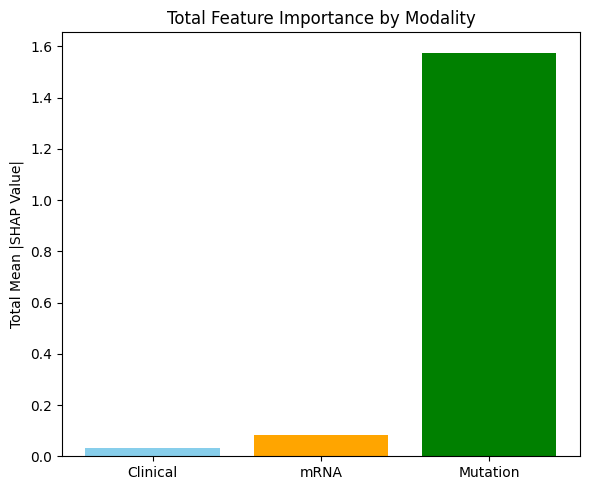

In [42]:
# Compute mean absolute SHAP values per feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
print(mean_abs_shap)

# Sum total importance per modality
clinical_importance = mean_abs_shap[:clin_dim].sum()
mrna_importance = mean_abs_shap[clin_dim:clin_dim + mrna_dim].sum()
mutation_importance = mean_abs_shap[clin_dim + mrna_dim:].sum()

# Print results
print("\nTotal SHAP importance by modality:")
print(f"  Clinical: {clinical_importance:.4f}")
print(f"  mRNA: {mrna_importance:.4f}")
print(f"  Mutation: {mutation_importance:.4f}")

# Optional: plot total importance per modality
import matplotlib.pyplot as plt

modalities = ["Clinical", "mRNA", "Mutation"]
totals = [clinical_importance, mrna_importance, mutation_importance]

plt.figure(figsize=(6, 5))
plt.bar(modalities, totals, color=["skyblue", "orange", "green"])
plt.ylabel("Total Mean |SHAP Value|")
plt.title("Total Feature Importance by Modality")
plt.tight_layout()
plt.show()


In [43]:
import numpy as np

# Compute mean absolute SHAP values for all features
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Split SHAP values and feature names by modality
clin_shap = mean_abs_shap[:clin_dim]
mrna_shap = mean_abs_shap[clin_dim:clin_dim + mrna_dim]
mut_shap = mean_abs_shap[clin_dim + mrna_dim:]

clin_names = all_feature_names[:clin_dim]
mrna_names = all_feature_names[clin_dim:clin_dim + mrna_dim]
mut_names = all_feature_names[clin_dim + mrna_dim:]

def print_top_bottom_features(shap_array, names, modality, top_n=5):
    print(f"\n{modality} features:")

    # Top features
    top_indices = np.argsort(-shap_array)[:top_n]
    print(f"  Top {top_n} most important features:")
    for i, idx in enumerate(top_indices, 1):
        print(f"    {i}. {names[idx]}: {shap_array[idx]:.4f}")

    # Bottom features
    bottom_indices = np.argsort(shap_array)[:top_n]
    print(f"  Top {top_n} least important features:")
    for i, idx in enumerate(bottom_indices, 1):
        print(f"    {i}. {names[idx]}: {shap_array[idx]:.4f}")

# Print for each modality
print_top_bottom_features(clin_shap, clin_names, "Clinical")
print_top_bottom_features(mrna_shap, mrna_names, "mRNA")
print_top_bottom_features(mut_shap, mut_names, "Mutation")



Clinical features:
  Top 5 most important features:
    1. TMB_NONSYNONYMOUS: 0.0149
    2. TBL_SCORE: 0.0120
    3. WEIGHT: 0.0033
    4. MSI_SENSOR_SCORE: 0.0009
    5. AGE: 0.0007
  Top 5 least important features:
    1. ICD_O_3_HISTOLOGY_8460/3: 0.0000
    2. ICD_O_3_HISTOLOGY_8310/3: 0.0000
    3. GENETIC_ANCESTRY_LABEL_AFR: 0.0000
    4. CLINICAL_STAGE_stage IV: 0.0000
    5. CLINICAL_STAGE_stage IIa: 0.0000

mRNA features:
  Top 5 most important features:
    1. mrna_1063: 0.0003
    2. mrna_278: 0.0003
    3. mrna_325: 0.0003
    4. mrna_696: 0.0003
    5. mrna_1132: 0.0003
  Top 5 least important features:
    1. mrna_1062: 0.0000
    2. mrna_62: 0.0000
    3. mrna_403: 0.0000
    4. mrna_979: 0.0000
    5. mrna_473: 0.0000

Mutation features:
  Top 5 most important features:


IndexError: list index out of range